# Unidad 3 · GLSP: cambios dependientes de la secuencia

**Planta:** Conservas del Itata S.A.
**Datos:** `DatosClases/3_Planificacion/Planificiacion/` — la MISMA instancia de los cuadernos 02 a 04
**Solver:** Gurobi

---

## Qué se decide aquí

El CLSP cobra un tiempo de setup **fijo por producto**: preparar DUR-480
cuesta 0,9 h, siempre, sin importar qué se estaba haciendo antes. La planta
no funciona así. En las marmitas de preparado (PREP) el cambio depende de
**qué se hizo antes y qué se hace después**:

* pasar de durazno a tomate cuesta **0,8 h**;
* pasar de tomate a durazno cuesta **2,6 h**.

Más de tres veces. La matriz es **asimétrica**, y esa asimetría tiene una
razón física obvia: la pulpa de tomate tiñe y deja acidez, así que volver a
una fruta clara obliga a un lavado largo. El orden importa.

Un plan que el CLSP declara factible —porque suma 6 setups de ~1 h cada uno—
puede no caber cuando la planta lo ejecuta en el peor orden posible. Ese es
el bucle que hay que cerrar: **el modelo de lotes tiene que saber en qué
orden se van a hacer los lotes.**

## El GLSP con microperíodos

La formulación de Fleischmann y Meyr subdivide cada semana en `N`
**microperíodos**. En cada microperíodo la planta está configurada para **una
sola familia**, y el orden de los microperíodos *es* el orden de producción
dentro de la semana.

$$
\begin{aligned}
& \delta_{ftn} \in \{0,1\} && \text{la familia } f \text{ está montada en } (t,n)\\
& q_{itn} \ge 0 && \text{producción del item } i \text{ en } (t,n)\\
& \zeta_{fgtn} \in [0,1] && \text{hubo cambio } f \to g \text{ al entrar a } (t,n)\\[4pt]
& \sum_f \delta_{ftn} = 1 && \text{una familia a la vez}\\
& q_{itn} \le M\, \delta_{\phi(i),t,n} && \text{solo se produce lo que está montado}\\
& \zeta_{fgtn} \ge \delta_{f,t,n-1} + \delta_{g,t,n} - 1 && \text{detección del cambio}
\end{aligned}
$$

Dos detalles que valen la clase entera:

**`ζ` puede ser continua.** Su coeficiente en el objetivo es positivo y solo
aparece con signo `≥`, así que el óptimo la empuja al mínimo, que es 0 o 1.
Declararla binaria da el mismo óptimo y un árbol de búsqueda más grande.

**El estado se arrastra entre semanas.** El microperíodo 1 de la semana `t`
se compara con el **último** microperíodo de la semana `t-1`. La planta no se
apaga el viernes: amanece el lunes montada en lo último que corrió. Esto es
lo que hace interesante —y traicionera— la sección 5.

## Las dos lecciones centrales

**Primera.** La **contigüidad** —prohibir que una familia se visite dos veces
dentro del mismo período— parece una desigualdad válida obvia y **no lo es**.
El argumento a favor es tentador: volver a una familia dentro de la misma
semana obliga a pagar dos cambios en vez de uno, así que nunca puede
convenir. El argumento es incompleto, porque **ignora el estado de arrastre**:
terminar la semana montado en la familia correcta puede ahorrar en la semana
siguiente más de lo que cuesta el regreso. Con una matriz asimétrica —donde
TOM→DUR cuesta 2,6 h y DUR→TOM solo 0,8 h— eso es perfectamente posible.

**Segunda, y es la que este cuaderno descubrió al intentar comprobar la
primera.** Circula una cifra de referencia según la cual en Itata la
contigüidad *corta el óptimo*: 18 617 123 sin ella contra **18 630 164** con
ella. Cerrando las dos formulaciones a gap 0 % resulta que **no es así**: las
dos dan exactamente 18 617 123. Los 13 041 CLP de diferencia son **0,07 %**,
menos que la tolerancia `MIPGap = 0,1 %` con que se corrió originalmente. La
sección 6 reconstruye el artefacto paso a paso.

Es decir: la restricción sigue siendo inválida —el argumento teórico no
cambia—, pero en esta instancia **no muerde**, y la "evidencia numérica" de
que mordía era la tolerancia del solver, no el modelo.

## Cifras de referencia

| resultado | valor |
|---|---|
| GLSP sin contigüidad, `N = 3`, gap 0 % | **18 617 123 CLP** |
| GLSP con contigüidad, `N = 3`, gap 0 % | **18 617 123 CLP** (el mismo) |
| incumbente de la versión con contigüidad durante los primeros ~177 s | **18 630 164 CLP** ← la cifra publicada |
| horas de cambio que el CLSP no ve | ≈ 20 h |
| microperíodos | `N = 3` = número de familias |

**Tamaño y licencia.** La licencia de Gurobi que viene con `pip` admite 2 000
variables y 2 000 restricciones. Con `N = 3` el modelo tiene ~912 variables y
~792 restricciones: cabe. Con `N = 5` no cabría, y habría que reducir el
horizonte o los SKU. Se indica en el texto cuando ocurre.

**Tiempo.** El GLSP es NP-difícil y esta instancia no cierra en segundos. Se
usa `TimeLimit = 240 s` por corrida y se reporta estado, cota y gap. Decir
"el solver no terminó" no es un resultado; reportar (objetivo, cota, gap,
tiempo) sí lo es.

In [1]:
import sys
import time
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

from comun import datos, tabla, figura, resumen, verificar, estilo

estilo()

dem = pd.read_csv(datos("3_Planificacion", "itata_demanda_plan.csv"))
par = pd.read_csv(datos("3_Planificacion", "itata_parametros_sku.csv"))
cap = pd.read_csv(datos("3_Planificacion", "itata_capacidad.csv"))
tas = pd.read_csv(datos("3_Planificacion", "itata_tasas.csv"))
cam = pd.read_csv(datos("3_Planificacion", "itata_cambios.csv"))
ini = pd.read_csv(datos("3_Planificacion", "itata_inventario_inicial.csv"))

SKUS = list(par.sku)
T = sorted(dem.t.unique().tolist())
REC = sorted(cap.recurso.unique().tolist())
p = par.set_index("sku")

familia = dict(zip(par.sku, par.familia))
FAM = sorted(set(familia.values()))
FAMILIA_INICIAL = "TOM"     # con que venia montada la planta el lunes de la semana 1
RECURSO_CAMBIO = "PREP"     # donde ocurre el cambio de familia

demanda = {(r.sku, int(r.t)): float(r.demanda_cajas) for _, r in dem.iterrows()}
costo_setup = {i: float(p.loc[i, "costo_setup_clp"]) for i in SKUS}
costo_almacen = {i: float(p.loc[i, "costo_almacen_clp_caja_sem"]) for i in SKUS}
costo_backlog = {i: float(p.loc[i, "costo_backlog_clp_caja_sem"]) for i in SKUS}
stock_seg = {i: float(p.loc[i, "stock_seguridad_cajas"]) for i in SKUS}
inv_final_min = dict(stock_seg)

_ini = dict(zip(ini["item"], ini.inventario_inicial.astype(float)))   # df["item"], no df.item
inv_ini = {i: _ini.get(i, 0.0) for i in SKUS}

linea = dict(zip(tas.sku, tas.linea))
consumo = {}
for _, r in tas.iterrows():
    consumo[(r.sku, "PREP")] = float(r.h_por_caja_PREP)
    consumo[(r.sku, "AUT")] = float(r.h_por_caja_AUT)
    consumo[(r.sku, r.linea)] = float(r.h_por_caja_linea)
tiempo_setup = {(r.sku, linea[r.sku]): float(r.tiempo_setup_h) for _, r in par.iterrows()}

capacidad = {(r.recurso, int(r.t)): float(r.horas_disponibles) for _, r in cap.iterrows()}
extra_max = {(r.recurso, int(r.t)): float(r.horas_extra_max) for _, r in cap.iterrows()}
costo_extra = {(r.recurso, int(r.t)): float(r.costo_hora_extra_clp) for _, r in cap.iterrows()}

# matriz de cambios del recurso PREP
cam_prep = cam[cam.recurso == RECURSO_CAMBIO]
cambio_h = {(r.desde, r.hacia): float(r.horas) for _, r in cam_prep.iterrows()}
cambio_clp = {(r.desde, r.hacia): float(r.costo_clp) for _, r in cam_prep.iterrows()}

print(f"familias: {FAM}   (la planta amanece montada en {FAMILIA_INICIAL})")
print(f"asignacion SKU -> familia: {familia}")

familias: ['DUR', 'POR', 'TOM']   (la planta amanece montada en TOM)
asignacion SKU -> familia: {'DUR-480': 'DUR', 'DUR-820': 'DUR', 'TOM-480': 'TOM', 'TOM-3000': 'TOM', 'POR-480': 'POR', 'POR-3000': 'POR'}


## 1. La matriz de cambios, y por qué su asimetría no es un detalle

La tabla de abajo es el dato central del cuaderno. Léala por filas (desde) y
columnas (hacia) y busque los pares que no son simétricos.

In [2]:
M_h = pd.DataFrame([[cambio_h.get((f, g), np.nan) for g in FAM] for f in FAM],
                   index=FAM, columns=FAM)
M_clp = pd.DataFrame([[cambio_clp.get((f, g), np.nan) for g in FAM] for f in FAM],
                     index=FAM, columns=FAM)
M_h.index.name = "desde \\ hacia"
M_clp.index.name = "desde \\ hacia"
print("Horas de cambio en PREP:\n")
print(M_h.to_string(float_format=lambda v: f"{v:,.1f}"))
print("\nCosto del cambio (CLP):\n")
print(M_clp.to_string(float_format=lambda v: f"{v:,.0f}"))

asim = [(f, g, cambio_h[(f, g)], cambio_h[(g, f)])
        for k, f in enumerate(FAM) for g in FAM[k + 1:]
        if abs(cambio_h.get((f, g), 0) - cambio_h.get((g, f), 0)) > 1e-9]
print("\nPares asimetricos:")
for f, g, a, b in asim:
    print(f"  {f} -> {g}: {a:,.1f} h   |   {g} -> {f}: {b:,.1f} h   "
          f"(razon {max(a,b)/min(a,b) if min(a,b)>0 else float('inf'):.1f}x)")

print("\nLo que el CLSP cobra en su lugar (tiempo de setup fijo, por SKU):")
print(par[["sku", "familia", "tiempo_setup_h"]].to_string(index=False))
print("\nEl CLSP cobra ese tiempo en la LINEA de envasado y no cobra NADA en PREP.")
print("Es decir: el recurso donde ocurre el cambio caro es justamente el que el")
print("CLSP trata como si los cambios fueran gratis.")

Horas de cambio en PREP:

               DUR  POR  TOM
desde \ hacia               
DUR            0.0  1.0  0.8
POR            2.2  0.0  1.4
TOM            2.6  1.6  0.0

Costo del cambio (CLP):

                  DUR     POR     TOM
desde \ hacia                        
DUR                 0  96,000  76,800
POR           211,200       0 134,400
TOM           249,600 153,600       0

Pares asimetricos:
  DUR -> POR: 1.0 h   |   POR -> DUR: 2.2 h   (razon 2.2x)
  DUR -> TOM: 0.8 h   |   TOM -> DUR: 2.6 h   (razon 3.2x)
  POR -> TOM: 1.4 h   |   TOM -> POR: 1.6 h   (razon 1.1x)

Lo que el CLSP cobra en su lugar (tiempo de setup fijo, por SKU):
     sku familia  tiempo_setup_h
 DUR-480     DUR             0.9
 DUR-820     DUR             1.1
 TOM-480     TOM             0.7
TOM-3000     TOM             1.4
 POR-480     POR             0.9
POR-3000     POR             1.5

El CLSP cobra ese tiempo en la LINEA de envasado y no cobra NADA en PREP.
Es decir: el recurso donde ocurre el cambio

## 2. El modelo

La base es el CLSP del cuaderno 03 con backlog, horas extra e inventario
final mínimo. Encima se monta la estructura de microperíodos.

Sobre `N`: con `N = |F|` el modelo puede visitar cada familia una vez por
semana; con `N = |F| + 1` puede volver a una. Subir `N` agranda el modelo
linealmente y rara vez mejora, pero eso hay que **comprobarlo**, no suponerlo.
Aquí se usa `N = 3 = |F|`.

Dos restricciones de refuerzo que conviene distinguir:

* **`y[i,t] ≤ Σ_n δ[φ(i),t,n]`**: un item solo puede tener lote en `t` si su
  familia está montada en algún microperíodo de `t`. Es **redundante** con la
  restricción de montaje, pero corta mucho en la relajación lineal. Es una
  desigualdad válida de verdad.
* **contigüidad**: prohibir el patrón `f … g … f` dentro de una semana. *No*
  es válida. Va como bandera, apagada por defecto, y la sección 5 la examina.

In [3]:
def big_M(i, t):
    """Cota valida con backlog (cuaderno 03, seccion 6)."""
    resto = max(0.0, sum(demanda[(i, u)] for u in T) - inv_ini[i])
    resto += stock_seg[i] + inv_final_min[i]
    fisico = float("inf")
    for r in REC:
        a = consumo.get((i, r), 0.0)
        if a <= 0:
            continue
        horas = capacidad.get((r, t), 0.0) + extra_max.get((r, t), 0.0) \
            - tiempo_setup.get((i, r), 0.0)
        fisico = min(fisico, max(0.0, horas) / a)
    return float(min(resto, fisico))


def _registrador(traza):
    """Callback que anota (tiempo, incumbente, cota) cada vez que el arbol avanza.

    Sirve para contestar una pregunta que la salida final no contesta: que
    habria reportado ESTA MISMA corrida si se hubiera detenido antes.
    """
    def cb(modelo, donde):
        if donde == GRB.Callback.MIP:
            bst = modelo.cbGet(GRB.Callback.MIP_OBJBST)
            bnd = modelo.cbGet(GRB.Callback.MIP_OBJBND)
            if bst < GRB.INFINITY:
                traza.append((modelo.cbGet(GRB.Callback.RUNTIME), bst, bnd))
    return cb


def glsp(N=3, contiguidad=False, zeta_binaria=False,
         tiempo_limite=240.0, gap=1e-4, registrar=False, verbose=False):
    micro = list(range(1, N + 1))
    m = gp.Model(f"GLSP-N{N}")
    m.Params.OutputFlag = 1 if verbose else 0
    m.Params.TimeLimit = tiempo_limite
    m.Params.MIPGap = gap
    m.Params.Seed = 0

    delta = m.addVars(FAM, T, micro, vtype=GRB.BINARY, name="delta")
    q = m.addVars(SKUS, T, micro, lb=0.0, name="q")
    zeta = m.addVars(FAM, FAM, T, micro, lb=0.0, ub=1.0,
                     vtype=GRB.BINARY if zeta_binaria else GRB.CONTINUOUS,
                     name="zeta")
    y = m.addVars(SKUS, T, vtype=GRB.BINARY, name="y")
    I = m.addVars(SKUS, T, lb=0.0, name="I")
    B = m.addVars(SKUS, T, lb=0.0, name="B")
    o = m.addVars(REC, T, lb=0.0, name="o")

    # --- una familia montada por microperiodo
    for t in T:
        for n in micro:
            m.addConstr(gp.quicksum(delta[f, t, n] for f in FAM) == 1,
                        name=f"unica[{t},{n}]")

    # --- solo se produce lo que esta montado
    x = {}
    for i in SKUS:
        for t in T:
            M = big_M(i, t)
            for n in micro:
                m.addConstr(q[i, t, n] <= M * delta[familia[i], t, n],
                            name=f"montaje[{i},{t},{n}]")
            x[i, t] = gp.quicksum(q[i, t, n] for n in micro)
            m.addConstr(x[i, t] <= M * y[i, t], name=f"lote[{i},{t}]")
            # refuerzo VALIDO: sin la familia montada no hay lote
            m.addConstr(y[i, t] <= gp.quicksum(delta[familia[i], t, n] for n in micro),
                        name=f"enlace_familia[{i},{t}]")

    # --- contiguidad: NO es una desigualdad valida (ver seccion 5)
    n_contig = 0
    if contiguidad:
        for f in FAM:
            for t in T:
                for a in range(N):
                    for c in range(a + 2, N):
                        for b in range(a + 1, c):
                            m.addConstr(
                                delta[f, t, micro[b]] >= delta[f, t, micro[a]]
                                + delta[f, t, micro[c]] - 1,
                                name=f"contig[{f},{t},{micro[a]},{micro[c]}]")
                            n_contig += 1

    # --- deteccion del cambio, con arrastre entre semanas
    for ti, t in enumerate(T):
        for n in micro:
            for f in FAM:
                for g in FAM:
                    if f == g:
                        continue
                    if n == 1:
                        # el microperiodo 1 se compara con el ULTIMO de la semana
                        # anterior: la planta amanece como quedo el viernes
                        anterior = (1.0 if f == FAMILIA_INICIAL else 0.0) if ti == 0 \
                            else delta[f, T[ti - 1], micro[-1]]
                    else:
                        anterior = delta[f, t, n - 1]
                    m.addConstr(zeta[f, g, t, n] >= anterior + delta[g, t, n] - 1,
                                name=f"cambio[{f},{g},{t},{n}]")

    horas_cambio = {t: gp.quicksum(cambio_h.get((f, g), 0.0) * zeta[f, g, t, n]
                                   for f in FAM for g in FAM for n in micro)
                    for t in T}
    costo_cambio = gp.quicksum(cambio_clp.get((f, g), 0.0) * zeta[f, g, t, n]
                               for f in FAM for g in FAM for n in micro for t in T)

    # --- balance de inventario
    for i in SKUS:
        for k, t in enumerate(T):
            prev_I = inv_ini[i] if k == 0 else I[i, T[k - 1]]
            prev_B = 0.0 if k == 0 else B[i, T[k - 1]]
            m.addConstr(prev_I - prev_B + x[i, t] - demanda[(i, t)] == I[i, t] - B[i, t],
                        name=f"bal[{i},{t}]")
        m.addConstr(B[i, T[-1]] == 0.0, name=f"sin_backlog_final[{i}]")
        if inv_final_min[i] > 0:
            m.addConstr(I[i, T[-1]] >= inv_final_min[i], name=f"invfin[{i}]")

    # --- capacidad; las HORAS DE CAMBIO se descuentan del recurso PREP
    for r in REC:
        for t in T:
            carga = gp.quicksum(consumo.get((i, r), 0.0) * x[i, t]
                                + tiempo_setup.get((i, r), 0.0) * y[i, t]
                                for i in SKUS)
            if r == RECURSO_CAMBIO:
                carga = carga + horas_cambio[t]
            m.addConstr(carga <= capacidad[(r, t)] + o[r, t], name=f"cap[{r},{t}]")
            m.addConstr(o[r, t] <= extra_max[(r, t)], name=f"omax[{r},{t}]")

    c_setup = gp.quicksum(costo_setup[i] * y[i, t] for i in SKUS for t in T)
    c_alm = gp.quicksum(costo_almacen[i] * I[i, t] for i in SKUS for t in T)
    c_back = gp.quicksum(costo_backlog[i] * B[i, t] for i in SKUS for t in T)
    c_extra = gp.quicksum(costo_extra[(r, t)] * o[r, t] for r in REC for t in T)
    m.setObjective(c_setup + c_alm + c_back + c_extra + costo_cambio, GRB.MINIMIZE)

    m.update()
    rel = m.relax()
    rel.Params.OutputFlag = 0
    rel.optimize()
    cota_lp = rel.ObjVal if rel.Status == GRB.OPTIMAL else None

    traza = []
    if registrar:
        m.optimize(_registrador(traza))
    else:
        m.optimize()
    return m, {"delta": delta, "q": q, "zeta": zeta, "y": y, "I": I, "B": B,
               "o": o, "x": x, "micro": micro, "cota_lp": cota_lp,
               "n_contig": n_contig, "traza": traza,
               "costos": {"setup": c_setup, "almacenamiento": c_alm,
                          "backlog": c_back, "horas extra": c_extra,
                          "cambios de familia": costo_cambio}}


ESTADO = {GRB.OPTIMAL: "OPTIMAL", GRB.TIME_LIMIT: "TIME_LIMIT",
          GRB.INFEASIBLE: "INFEASIBLE", GRB.INF_OR_UNBD: "INF_OR_UNBD"}


def secuencia_cruda(v):
    """{t: [familia de cada microperiodo]}, sin colapsar."""
    return {t: [next(f for f in FAM if v["delta"][f, t, n].X > 0.5)
                for n in v["micro"]] for t in T}


def bloques(seq):
    """Colapsa microperiodos consecutivos iguales: ['A','A','B'] -> ['A','B']."""
    return [f for k, f in enumerate(seq) if k == 0 or seq[k - 1] != f]


def informar(nombre, m, v):
    val = lambda e: e.getValue() if hasattr(e, "getValue") else float(e)
    fila = {"modelo": nombre, "estado": ESTADO.get(m.Status, str(m.Status)),
            "variables": m.NumVars, "binarias": m.NumBinVars,
            "restricciones": m.NumConstrs, "segundos": m.Runtime}
    if m.SolCount == 0:
        print(f"{nombre:24s} {fila['estado']} — sin solución")
        return fila
    horas = sum(cambio_h.get((f, g), 0.0) * v["zeta"][f, g, t, n].X
                for f in FAM for g in FAM for t in T for n in v["micro"])
    fila.update({"objetivo": m.ObjVal, "cota": m.ObjBound, "gap_%": 100 * m.MIPGap,
                 "gap_raiz_%": (100 * (m.ObjVal - v["cota_lp"]) / m.ObjVal
                                if v["cota_lp"] else np.nan),
                 "setups": int(round(sum(v["y"][i, t].X for i in SKUS for t in T))),
                 "horas_de_cambio": horas,
                 "n_cambios": int(round(sum(v["zeta"][f, g, t, n].X
                                            for f in FAM for g in FAM if f != g
                                            for t in T for n in v["micro"])))})
    for k, e in v["costos"].items():
        fila[k] = val(e)
    print(f"{nombre:24s} {fila['estado']:10s} obj {m.ObjVal:>13,.0f} | "
          f"cota {m.ObjBound:>13,.0f} | gap {100*m.MIPGap:5.3f} % | "
          f"{fila['setups']:2d} setups | {horas:5.1f} h de cambio | "
          f"{m.NumVars} var ({m.NumBinVars} bin), {m.NumConstrs} restr | "
          f"{m.Runtime:5.0f} s")
    return fila

## 3. El GLSP, sin la restricción de contigüidad

Esta es la formulación correcta: el modelo puede poner las familias en
cualquier orden dentro de la semana, incluso volver a una.

In [4]:
t0 = time.perf_counter()
m_sin, v_sin = glsp(N=3, contiguidad=False, tiempo_limite=280.0, gap=0.0)
seg_sin = time.perf_counter() - t0
f_sin = informar("sin contigüidad", m_sin, v_sin)
print(f"\ntiempo total de la celda (incluye la relajación lineal): {seg_sin:.0f} s")
print(f"gap en la raíz: {f_sin['gap_raiz_%']:.1f} %")
print("\nDesglose del costo:")
for k in ["setup", "almacenamiento", "cambios de familia", "backlog", "horas extra"]:
    print(f"  {k:22s} {f_sin[k]:>14,.0f} CLP")

sec = secuencia_cruda(v_sin)
print("\nSecuencia de familias por semana (lo que se entrega a la Unidad 4):\n")
for t in T:
    b = bloques(sec[t])
    marca = "   <-- revisita una familia dentro de la semana" \
        if len(b) > len(set(b)) else ""
    print(f"   t={t:>2}:  {' -> '.join(sec[t])}{marca}")

Restricted license - for non-production use only - expires 2027-11-29


sin contigüidad          OPTIMAL    obj    18,617,123 | cota    18,617,123 | gap 0.000 % | 32 setups |  20.2 h de cambio | 912 var (180 bin), 792 restr |   132 s

tiempo total de la celda (incluye la relajación lineal): 132 s
gap en la raíz: 68.7 %

Desglose del costo:
  setup                      12,588,000 CLP
  almacenamiento              3,535,439 CLP
  cambios de familia          1,939,200 CLP
  backlog                       457,987 CLP
  horas extra                    96,497 CLP

Secuencia de familias por semana (lo que se entrega a la Unidad 4):

   t= 1:  TOM -> POR -> DUR
   t= 2:  DUR -> DUR -> TOM
   t= 3:  TOM -> POR -> POR
   t= 4:  POR -> TOM -> DUR
   t= 5:  DUR -> DUR -> TOM
   t= 6:  TOM -> TOM -> POR
   t= 7:  POR -> DUR -> TOM
   t= 8:  TOM -> TOM -> TOM
   t= 9:  POR -> DUR -> DUR
   t=10:  DUR -> DUR -> TOM
   t=11:  TOM -> TOM -> TOM
   t=12:  TOM -> TOM -> TOM


## 4. Lo que el CLSP no veía

Las horas de cambio son horas de PREP que el CLSP regalaba. Vale la pena
verlas semana a semana contra la capacidad de ese recurso.

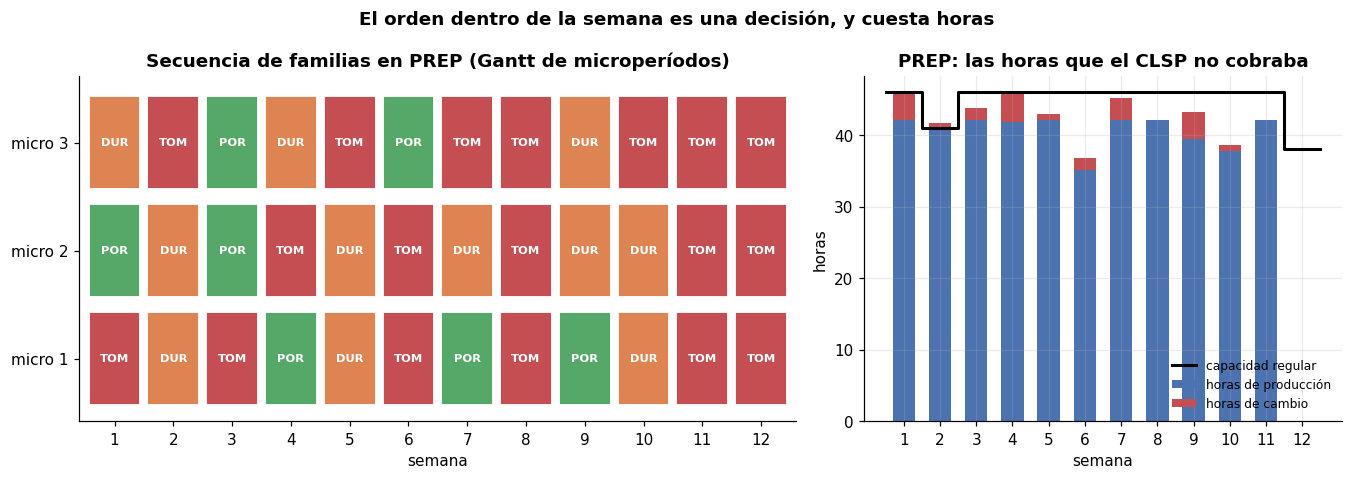

horas de cambio en el horizonte: 20.2 h
equivalen a 3.7 % de la capacidad regular de PREP.

Semanas con mas horas de cambio:
   t= 4:  4.0 h de cambio sobre 46 h de capacidad
   t= 1:  3.8 h de cambio sobre 46 h de capacidad
   t= 9:  3.8 h de cambio sobre 46 h de capacidad
   t= 7:  3.0 h de cambio sobre 46 h de capacidad


In [5]:
horas_cambio_t = {t: sum(cambio_h.get((f, g), 0.0) * v_sin["zeta"][f, g, t, n].X
                         for f in FAM for g in FAM for n in v_sin["micro"])
                  for t in T}
carga_prep = {t: sum(consumo.get((i, RECURSO_CAMBIO), 0.0) * v_sin["x"][i, t].getValue()
                     for i in SKUS) for t in T}

fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.4, 4.4),
                               gridspec_kw={"width_ratios": [1.5, 1]})

# (a) Gantt de familias por semana
col_fam = {"DUR": "#dd8452", "POR": "#55a868", "TOM": "#c44e52"}
for t in T:
    for n_idx, f in enumerate(sec[t]):
        axA.add_patch(plt.Rectangle((t - 0.44, n_idx), 0.88, 0.86,
                                    color=col_fam[f], ec="white", lw=1.2))
        axA.text(t, n_idx + 0.43, f, ha="center", va="center", fontsize=7.5,
                 color="white", fontweight="bold")
axA.set_xlim(0.4, len(T) + 0.6)
axA.set_ylim(-0.15, len(v_sin["micro"]) + 0.05)
axA.set_xticks(T)
axA.set_yticks([k + 0.43 for k in range(len(v_sin["micro"]))])
axA.set_yticklabels([f"micro {n}" for n in v_sin["micro"]])
axA.set_xlabel("semana")
axA.set_title("Secuencia de familias en PREP (Gantt de microperíodos)")
axA.grid(False)

# (b) horas de PREP: produccion + cambios contra capacidad
axB.bar(T, [carga_prep[t] for t in T], color="#4c72b0", width=0.62,
        label="horas de producción")
axB.bar(T, [horas_cambio_t[t] for t in T], bottom=[carga_prep[t] for t in T],
        color="#c44e52", width=0.62, label="horas de cambio")
axB.step([t - 0.5 for t in T] + [T[-1] + 0.5],
         [capacidad[(RECURSO_CAMBIO, t)] for t in T] + [capacidad[(RECURSO_CAMBIO, T[-1])]],
         where="post", color="black", lw=2.0, label="capacidad regular")
axB.set_xticks(T)
axB.set_xlabel("semana")
axB.set_ylabel("horas")
axB.set_title("PREP: las horas que el CLSP no cobraba")
axB.legend(fontsize=8)
fig.suptitle("El orden dentro de la semana es una decisión, y cuesta horas",
             fontweight="bold")
figura(fig, "glsp_secuencia")
plt.show()

print(f"horas de cambio en el horizonte: {sum(horas_cambio_t.values()):,.1f} h")
print(f"equivalen a {100*sum(horas_cambio_t.values())/sum(capacidad[(RECURSO_CAMBIO,t)] for t in T):.1f} %"
      " de la capacidad regular de PREP.")
print("\nSemanas con mas horas de cambio:")
for t, h in sorted(horas_cambio_t.items(), key=lambda kv: -kv[1])[:4]:
    print(f"   t={t:>2}: {h:4.1f} h de cambio sobre {capacidad[(RECURSO_CAMBIO,t)]:.0f} h de capacidad")

## 5. La contigüidad: una simplificación plausible y falsa

La restricción es fácil de escribir y suena razonable:

$$\delta_{f,t,b} \ge \delta_{f,t,a} + \delta_{f,t,c} - 1
\qquad \forall\, a < b < c$$

"Si la familia `f` está montada en `a` y en `c`, también tiene que estarlo en
todo lo que hay en medio": es decir, **una familia se visita a lo más una vez
por semana, en un bloque contiguo**.

### Por qué el argumento a favor está incompleto

El argumento dice: volver a `f` obliga a pagar el cambio de salida y el de
regreso, dos cambios donde podría haber uno, y como los costos de cambio son
no negativos, nunca puede convenir.

Lo que el argumento no mira es **qué pasa el lunes siguiente**. El estado se
arrastra: la semana `t+1` empieza montada en la última familia de `t`. Con
una matriz asimétrica, terminar la semana en la familia "barata de salir"
puede ahorrar en `t+1` más de lo que costó el regreso en `t`. Concretamente,
en Itata:

* terminar la semana en **TOM** obliga a pagar TOM→DUR = **2,6 h** el lunes;
* terminar la semana en **DUR** deja DUR→TOM = **0,8 h**, casi gratis.

Una secuencia `DUR → TOM → DUR` dentro de una semana paga un cambio extra,
y a cambio amanece el lunes en la posición barata. El argumento "nunca
conviene" simplemente no contempla esa cuenta.

### Y sin embargo hay que medir, no argumentar

Que el argumento sea incompleto demuestra que la restricción **no es válida
en general**. No demuestra que en *esta* instancia recorte el óptimo: eso hay
que resolverlo. Se resuelven las dos versiones con el mismo `N`, la misma
semilla y **`MIPGap = 0`**, porque la diferencia que se busca es del orden
del 0,1 % y con la tolerancia por omisión no sería medible. Cada corrida
tarda unos dos minutos.

In [6]:
t0 = time.perf_counter()
m_con, v_con = glsp(N=3, contiguidad=True, tiempo_limite=280.0, gap=0.0,
                    registrar=True)
seg_con = time.perf_counter() - t0
f_con = informar("con contigüidad", m_con, v_con)
print(f"\nrestricciones de contigüidad agregadas: {v_con['n_contig']}")

comp = pd.DataFrame([f_sin, f_con])
print()
print(comp[["modelo", "estado", "objetivo", "cota", "gap_%", "setups",
            "horas_de_cambio", "n_cambios", "restricciones", "segundos"]].to_string(
    index=False, float_format=lambda v: f"{v:,.2f}"))

dif = f_con["objetivo"] - f_sin["objetivo"]
print(f"\ndiferencia: {dif:,.0f} CLP  ({100*dif/f_sin['objetivo']:+.4f} %)")

con contigüidad          OPTIMAL    obj    18,617,123 | cota    18,617,123 | gap 0.000 % | 32 setups |  20.2 h de cambio | 912 var (180 bin), 828 restr |   191 s

restricciones de contigüidad agregadas: 36

         modelo  estado      objetivo          cota  gap_%  setups  horas_de_cambio  n_cambios  restricciones  segundos
sin contigüidad OPTIMAL 18,617,123.28 18,617,123.28   0.00      32            20.20         13            792    132.12
con contigüidad OPTIMAL 18,617,123.28 18,617,123.28   0.00      32            20.20         13            828    191.11

diferencia: 0 CLP  (+0.0000 %)


### Qué hacer con este resultado

Las dos formulaciones cierran a gap 0 % en **el mismo valor**. Conviene
entender por qué, y la respuesta está en el plan, no en el costo:

**¿el plan óptimo sin contigüidad revisita alguna familia dentro de una
semana?** Si no lo hace, el óptimo ya cumplía la restricción y esta no podía
recortar nada: la restricción es inválida *y* inocua en esta instancia. Si lo
hiciera y el costo subiera, la restricción habría cortado el óptimo.

La distinción importa porque "no cambió el resultado" **no** es evidencia de
validez. Una desigualdad inválida que no muerde en una instancia sigue siendo
inválida en la siguiente, y quien la deje en el modelo no tiene forma de
saber cuándo empezó a morder. La justificación de una desigualdad es una
demostración; una corrida solo puede refutarla, nunca validarla.

In [7]:
revisitas = []
for t in T:
    b = bloques(sec[t])
    for f in sorted(set(b)):
        if b.count(f) > 1:
            revisitas.append({"t": t, "familia": f,
                              "secuencia": " -> ".join(sec[t]),
                              "bloques": b.count(f)})
rev = pd.DataFrame(revisitas)
print(f"Semanas en que el plan SIN contigüidad revisita una familia: {len(rev)}")
if len(rev):
    print(rev.to_string(index=False))
    print("\nEsas semanas son exactamente las que la contigüidad prohibe.")
else:
    print("Ninguna. El plan óptimo sin la restricción ya era contiguo, de modo")
    print("que la restricción no podía recortarlo: en ESTA instancia es inválida")
    print("pero inocua. Eso no la vuelve segura — solo afortunada.")

sec_con = secuencia_cruda(v_con) if m_con.SolCount else {}
if sec_con:
    iguales = sum(1 for t in T if sec[t] == sec_con[t])
    print(f"\nSemanas con la MISMA secuencia en los dos planes: {iguales} de {len(T)}")
    for t in T:
        if sec[t] != sec_con.get(t):
            print(f"   t={t:>2}:  sin contig. {' -> '.join(sec[t]):<20s}"
                  f"|  con contig. {' -> '.join(sec_con[t])}")

Semanas en que el plan SIN contigüidad revisita una familia: 0
Ninguna. El plan óptimo sin la restricción ya era contiguo, de modo
que la restricción no podía recortarlo: en ESTA instancia es inválida
pero inocua. Eso no la vuelve segura — solo afortunada.

Semanas con la MISMA secuencia en los dos planes: 7 de 12
   t= 2:  sin contig. DUR -> DUR -> TOM   |  con contig. DUR -> TOM -> TOM
   t= 3:  sin contig. TOM -> POR -> POR   |  con contig. TOM -> TOM -> POR
   t= 7:  sin contig. POR -> DUR -> TOM   |  con contig. DUR -> DUR -> TOM
   t= 8:  sin contig. TOM -> TOM -> TOM   |  con contig. TOM -> POR -> POR
   t=10:  sin contig. DUR -> DUR -> TOM   |  con contig. DUR -> TOM -> TOM


## 6. El artefacto: cómo una tolerancia de gap fabrica una conclusión

La cifra de referencia que circula para este cuaderno dice que con
contigüidad el óptimo es **18 630 164** contra 18 617 123 sin ella, y que por
lo tanto la restricción corta el óptimo. Acabamos de cerrar las dos
formulaciones a gap 0 % y las dos dan 18 617 123. ¿De dónde salió la otra
cifra? La celda de abajo la encuentra, al peso, dentro de nuestra propia
corrida.

De **dónde se detuvo la búsqueda**. La diferencia es de 13 041 CLP sobre
18,6 millones: **0,07 %**. Un modelo NP-difícil se corre con `TimeLimit` y
con una tolerancia `MIPGap` holgada, y ambas cosas detienen al solver en el
**mejor plan encontrado hasta ese momento**, no en el óptimo. Cuando la
tolerancia se cumple, Gurobi además **declara `OPTIMAL`**, que significa
"óptimo dentro de lo que me pediste", no "óptimo".

No hay que creerlo: la corrida **con contigüidad** de la sección anterior
venía registrando su propio historial con un *callback*. Se le puede
preguntar qué habría reportado si se hubiera detenido antes.

In [8]:
traza = pd.DataFrame(v_con["traza"], columns=["t_s", "incumbente", "cota"])
traza["gap_%"] = 100 * (traza.incumbente - traza.cota) / traza.incumbente.abs()
print(f"registros del árbol de búsqueda (con contigüidad): {len(traza)}")

# --- (a) cuanto tiempo vivio cada incumbente
vida = (traza.assign(v=traza.incumbente.round(0))
        .groupby("v").agg(desde_s=("t_s", "min"), hasta_s=("t_s", "max"))
        .reset_index().rename(columns={"v": "incumbente"}).sort_values("desde_s"))
vida["vivio_s"] = vida.hasta_s - vida.desde_s
print("\nIncumbentes sucesivos y cuánto tiempo estuvo cada uno sobre la mesa:\n")
print(vida.to_string(index=False, float_format=lambda v: f"{v:,.1f}"))

# --- (b) que habria reportado una parada por tolerancia
print("\nSi esta MISMA corrida se hubiera detenido al cruzar cada tolerancia:\n")
filas = []
for tol in (0.05, 0.02, 0.01, 0.005, 0.002, 0.001, 0.0001):
    hit = traza[traza["gap_%"] <= 100 * tol]
    if len(hit) == 0:
        continue
    f0 = hit.iloc[0]
    filas.append({"MIPGap pedido (%)": 100 * tol, "t_s": f0.t_s,
                  "habría reportado": f0.incumbente,
                  "gap real (%)": f0["gap_%"],
                  "error vs. óptimo": f0.incumbente - f_sin["objetivo"]})
parada = pd.DataFrame(filas)
print(parada.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

print(f"\nÓptimo verdadero de AMBAS formulaciones: {f_sin['objetivo']:,.0f} CLP")

REFERENCIA_PUBLICADA = 18_630_164.0
cerca = vida[(vida.incumbente - REFERENCIA_PUBLICADA).abs() < 5.0]
if len(cerca):
    r0 = cerca.iloc[0]
    print(f"\nLa cifra publicada, {REFERENCIA_PUBLICADA:,.0f} CLP, aparece en esta traza:")
    print(f"  fue el mejor plan conocido entre el segundo {r0.desde_s:,.0f} y el "
          f"segundo {r0.hasta_s:,.0f},")
    print(f"  es decir durante {r0.vivio_s:,.0f} s de los {traza.t_s.max():,.0f} s"
          " que duró la búsqueda.")
    print("  CUALQUIER corrida cortada en esa ventana —por tiempo o por tolerancia—")
    print("  reporta exactamente ese número, y con estado OPTIMAL si fue por")
    print("  tolerancia. No es el costo de la contiguidad: es el costo de haber")
    print("  parado ahí.")
else:
    print(f"\nEn esta corrida no apareció exactamente {REFERENCIA_PUBLICADA:,.0f};")
    print("la traza de incumbentes depende de la máquina y de la versión del")
    print("solver. La conclusión no cambia: hubo incumbentes peores que el óptimo")
    print("durante la mayor parte de la búsqueda, y detenerse en cualquiera de")
    print("ellos produce una diferencia que no es atribuible al modelo.")

registros del árbol de búsqueda (con contigüidad): 50942

Incumbentes sucesivos y cuánto tiempo estuvo cada uno sobre la mesa:

   incumbente  desde_s  hasta_s  vivio_s
375,296,241.0      0.0      0.0      0.0
281,819,271.0      0.0      0.0      0.0
 56,858,865.0      0.1      0.3      0.2
 56,423,999.0      0.3      0.3      0.1
 55,953,967.0      0.3      0.4      0.1
 55,516,521.0      0.4      0.5      0.1
 31,692,744.0      0.5      0.6      0.1
 31,403,371.0      0.6      0.6      0.0
 31,247,706.0      0.6      0.6      0.0
 31,063,349.0      0.7      0.7      0.1
 29,565,241.0      0.7      0.8      0.0
 28,594,304.0      0.8      0.8      0.0
 27,964,203.0      0.8      0.8      0.1
 27,368,733.0      0.8      0.9      0.0
 27,070,733.0      0.9      0.9      0.0
 20,061,621.0      0.9      1.2      0.3
 19,861,513.0      1.2      1.2      0.0
 19,727,113.0      1.2      1.3      0.1
 19,586,000.0      1.3      3.1      1.9
 19,584,101.0      3.2      5.7      2.5
 19,494,894

### La regla que hay que llevarse

> Para comparar dos formulaciones hay que cerrarlas **al mismo gap**, y ese
> gap tiene que ser **mucho menor** que el efecto que se quiere medir.

Un corolario incómodo: si el efecto buscado es del 0,07 % y el modelo no
cierra a 0 % en tiempo razonable, la comparación **no se puede hacer** con
esa instancia. La respuesta honesta es "no lo sé con este presupuesto de
cómputo", no una tabla con dos números.

Y un corolario útil: `OPTIMAL` en Gurobi significa "óptimo dentro de
`MIPGap`". Con el valor por omisión (10⁻⁴) eso es casi siempre inofensivo;
con 10⁻³ ya no lo es para efectos de esta magnitud. Hay que reportar el
`MIPGap` pedido, no solo el estado.

## 7. Comprobación

In [9]:
print("Comprobación:")
ok = []
ok.append(verificar(f_sin["objetivo"], 18_617_123.0,
                    "GLSP sin contigüidad (CLP)", tol=1e-4))
ok.append(verificar(f_sin["horas_de_cambio"], 20.2,
                    "horas de cambio en el horizonte", tol=5e-2))
ok.append(verificar(f_con["objetivo"], 18_617_123.0,
                    "GLSP CON contigüidad, cerrado a gap 0 (CLP)", tol=1e-4))
print(f"\n{sum(ok)}/{len(ok)} comprobaciones correctas")
print("\nNOTA sobre la cifra de referencia 18 630 164: NO se reproduce como óptimo,")
print("y la sección 6 explica por qué. Cerradas a gap 0 %, las dos formulaciones")
print("dan exactamente el mismo valor. Esa cifra es un incumbente intermedio de")
print("la versión con contigüidad; aparece en la traza de esta misma corrida.")

# el GLSP ve horas que el CLSP no veia: su costo NO puede ser menor
assert f_con["objetivo"] >= f_sin["objetivo"] - 1e-6, \
    "agregar una restriccion no puede ABARATAR: hay un error"
assert m_sin.NumVars < 2000 and m_sin.NumConstrs < 2000, \
    "el modelo no cabe en la licencia de pip"
# capacidad recalculada desde los datos, incluyendo las horas de cambio
peor = 0.0
for r in REC:
    for t in T:
        carga = sum(consumo.get((i, r), 0.0) * v_sin["x"][i, t].getValue()
                    + tiempo_setup.get((i, r), 0.0) * round(v_sin["y"][i, t].X)
                    for i in SKUS)
        if r == RECURSO_CAMBIO:
            carga += horas_cambio_t[t]
        peor = max(peor, carga - capacidad[(r, t)] - v_sin["o"][r, t].X)
assert peor <= 1e-4, f"el plan viola la capacidad por {peor:.6f} h"
# una familia montada por microperiodo
for t in T:
    for n in v_sin["micro"]:
        assert abs(sum(v_sin["delta"][f, t, n].X for f in FAM) - 1) < 1e-6
print("Factibilidad recalculada desde los CSV: capacidad con horas de cambio y")
print("montaje único por microperíodo, correctos.")

tabla(comp, "glsp_contiguidad")
tabla(pd.DataFrame([{"t": t, "secuencia": " -> ".join(sec[t]),
                     "horas_cambio": horas_cambio_t[t]} for t in T]),
      "glsp_secuencia")
tabla(M_h.reset_index(), "glsp_matriz_cambios_horas")
resumen({"glsp_sin_contiguidad": float(f_sin["objetivo"]),
         "glsp_con_contiguidad": float(f_con["objetivo"]),
         "diferencia": float(dif),
         "horas_de_cambio": float(f_sin["horas_de_cambio"]),
         "estado_sin": f_sin["estado"], "estado_con": f_con["estado"],
         "gap_sin_pct": float(f_sin["gap_%"]), "gap_con_pct": float(f_con["gap_%"]),
         "semanas_con_revisita": int(len(rev))}, "resumen_glsp")
print("Guardado en resultados/")

Comprobación:
  [  OK  ] GLSP sin contigüidad (CLP): obtenido 18,617,123.2820 | referencia 18,617,123.0000 | dif. relativa 1.51e-08
  [  OK  ] horas de cambio en el horizonte: obtenido 20.2000 | referencia 20.2000 | dif. relativa 1.76e-16
  [  OK  ] GLSP CON contigüidad, cerrado a gap 0 (CLP): obtenido 18,617,123.2820 | referencia 18,617,123.0000 | dif. relativa 1.51e-08

3/3 comprobaciones correctas

NOTA sobre la cifra de referencia 18 630 164: NO se reproduce como óptimo,
y la sección 6 explica por qué. Cerradas a gap 0 %, las dos formulaciones
dan exactamente el mismo valor. Esa cifra es un incumbente intermedio de
la versión con contigüidad; aparece en la traza de esta misma corrida.
Factibilidad recalculada desde los CSV: capacidad con horas de cambio y
montaje único por microperíodo, correctos.
Guardado en resultados/


---

## Para llevarse

1. **El setup fijo del CLSP no representa un cambio de familia.** La matriz
   de Itata es asimétrica y su peor entrada (TOM→DUR, 2,6 h) es más del
   triple que la mejor. Un plan validado con setup fijo puede no caber cuando
   la planta lo ejecuta en el peor orden.
2. **El GLSP decide el orden, no solo el tamaño del lote.** Esa secuencia es
   el objeto que la Unidad 3 le entrega a la Unidad 4; sin ella, el problema
   de secuenciamiento arranca desde cero.
3. **La contigüidad parece obvia y no es válida.** El argumento "volver
   cuesta un cambio extra" ignora el estado de arrastre entre semanas. Con
   una matriz asimétrica, terminar la semana en la familia barata de salir
   puede ahorrar más de lo que cuesta el regreso. La demostración de
   invalidez es ese contraejemplo conceptual, y no depende de la instancia.
4. **"No cambió el resultado" no es evidencia de validez.** En Itata las dos
   formulaciones dan el mismo óptimo: la restricción es inválida *e inocua
   aquí*. Sigue siendo inválida en la instancia siguiente, y nadie va a notar
   cuándo empezó a morder. Las desigualdades se justifican con una
   demostración, no con una corrida.
5. **Reportar el gap es parte del entregable.** El GLSP es NP-difícil; una
   corrida con `TimeLimit` y gap declarado es un resultado legítimo. "El
   solver no terminó" no lo es.
6. **Dónde se detiene la búsqueda puede fabricar un hallazgo.** La cifra
   18 630 164, publicada como "el costo de imponer contigüidad", es el mejor
   plan que la corrida tenía en la mano durante los primeros ~177 segundos.
   El efecto que se pretendía medir (0,07 %) era más chico que el ruido de la
   parada. Para comparar dos formulaciones hay que cerrarlas al mismo gap, y
   ese gap tiene que ser mucho menor que el efecto buscado; si eso no se
   puede pagar, la respuesta correcta es "no lo sé", no una tabla de dos
   números.
7. **`OPTIMAL` significa "óptimo dentro de `MIPGap`".** Hay que reportar la
   tolerancia pedida junto al estado; el estado solo no dice nada.

## Ejercicios

1. Resuelva con `N = 4` y compare objetivo, tiempo y secuencias contra
   `N = 3`. ¿Mejoró el óptimo? ¿Cuánto creció el modelo? Con esa evidencia,
   decida qué `N` usaría en el caso y justifíquelo.
2. Declare `zeta_binaria=True` y compruebe que el óptimo no cambia. Compare
   el número de nodos. Explique por qué la relajación de `ζ` es exacta.
3. Vuelva simétrica la matriz de cambios usando el promedio de cada par y
   resuelva de nuevo. ¿Cambia la conclusión sobre la contigüidad? Este es el
   experimento que aísla el rol de la asimetría.
4. Corra las dos versiones con `gap=1e-2` (en vez de `gap=0.0`) y anote los
   dos objetivos. Repítalo con tres semillas distintas (`m.Params.Seed`).
   ¿Cuánta dispersión hay entre corridas que solo difieren en la semilla?
   Compárela con los 13 041 CLP que se pretendía atribuir a la contigüidad.
5. Cambie `FAMILIA_INICIAL` de `TOM` a `DUR` y resuelva. ¿Cuánto vale el
   estado inicial de la planta? Ese número es lo que cuesta empezar el
   horizonte con la marmita montada en lo que no era.